In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
SEED = 57

ModuleNotFoundError: No module named 'pandas'

## Завантаження даних

In [ ]:
df = pd.read_csv("../data/exam_dataset_1.csv")
df.head()

Розмір: (1000, 8)
Категорії: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Непарні категорії: [np.int64(1), np.int64(3), np.int64(5)]


,id,category,X1,X2,X3,X4,X5,target
0,0,4,7.719696,7.225326,6.591903,9.833928,7.503402,69.041729
1,1,4,5.663814,6.655295,10.396427,11.092169,8.209244,79.548400
2,2,3,7.910570,8.705756,9.554958,8.416181,6.257779,-71.008700
3,3,4,8.480861,6.883886,8.928048,9.050284,5.415433,-11.776024
4,4,5,5.965807,7.127756,8.126778,10.265996,7.239032,0.272058


## Статистика `target`

In [ ]:
odd_cats = sorted(c for c in df['category'].unique() if c % 2 != 0)
print(df['target'].describe().round(3))

for cat in odd_cats:
    sub = df[df['category'] == cat]['target']
    print(f"\n=== Непарна категорія {cat} (n={len(sub)}) ===")
    print(sub.describe().round(3))


=== Уся вибірка ===
count    1000.000
mean       16.434
std       108.623
min      -337.829
25%       -57.835
50%        15.276
75%        86.156
max       341.977
Name: target, dtype: float64

=== Непарна категорія 1 (n=194) ===
count    194.000
mean      13.880
std      117.155
min     -307.511
25%      -56.111
50%       21.369
75%       90.346
max      305.101
Name: target, dtype: float64

=== Непарна категорія 3 (n=191) ===
count    191.000
mean      12.244
std      104.728
min     -235.221
25%      -66.425
50%        6.209
75%       74.647
max      341.977
Name: target, dtype: float64

=== Непарна категорія 5 (n=216) ===
count    216.000
mean      14.610
std      111.836
min     -337.829
25%      -55.472
50%       13.566
75%       85.866
max      341.593
Name: target, dtype: float64


## Вибір кількості інтервалів

Оцінюємо оптимальну кількість бінів трьома правилами та обираємо найкраще для візуалізації.


In [ ]:
n = len(df)
target = df['target']

bins_sqrt   = int(np.ceil(np.sqrt(n)))
#bins_fd     = int(np.ceil((target.max() - target.min()) /
#                          (2 * (target.quantile(.75) - target.quantile(.25)) * n**(-1/3))))
print(f"√n    правило  → {bins_sqrt} бінів")

BINS_GLOBAL = bins_sqrt
print(f"\nОбрано: BINS_GLOBAL={BINS_GLOBAL}, BINS_CAT={bins_sqrt}")


√n    правило  → 32 бінів
Стьорджес      → 11 бінів
Фрідман–Діакон → 24 бінів

Обрано: BINS_GLOBAL=40, BINS_CAT=30


## Гістограма + щільність для всієї вибірки `target`

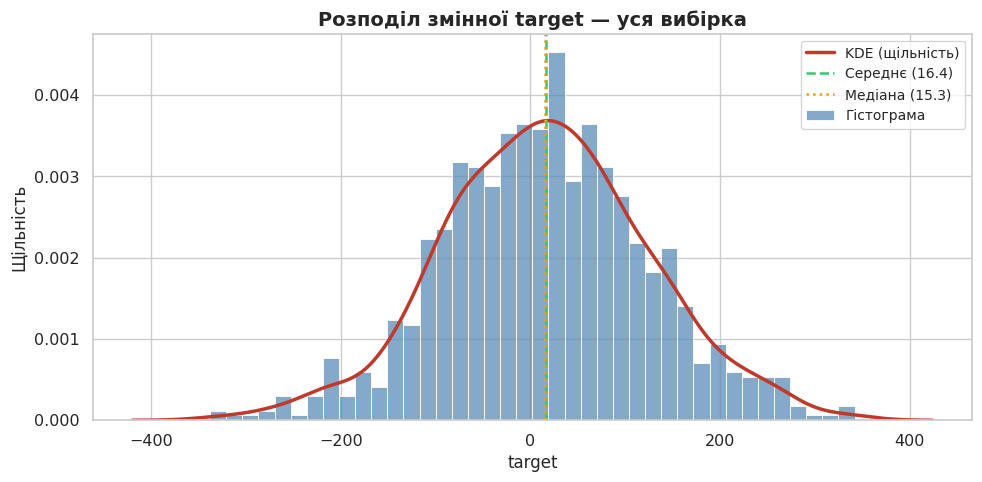

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['target'], bins=BINS_GLOBAL, ax=ax,
             color="#5b8db8", edgecolor="white", linewidth=0.6,
             stat="density", alpha=0.75, label="Гістограма")

sns.kdeplot(df['target'], ax=ax,
            color="#c0392b", linewidth=2.5, label="KDE (щільність)")

ax.set_title("Розподіл змінної target — уся вибірка", fontsize=14, fontweight="bold")
ax.set_xlabel("target", fontsize=12)
ax.set_ylabel("Щільність", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Гістограма + щільність для непарних категорій (окремо)

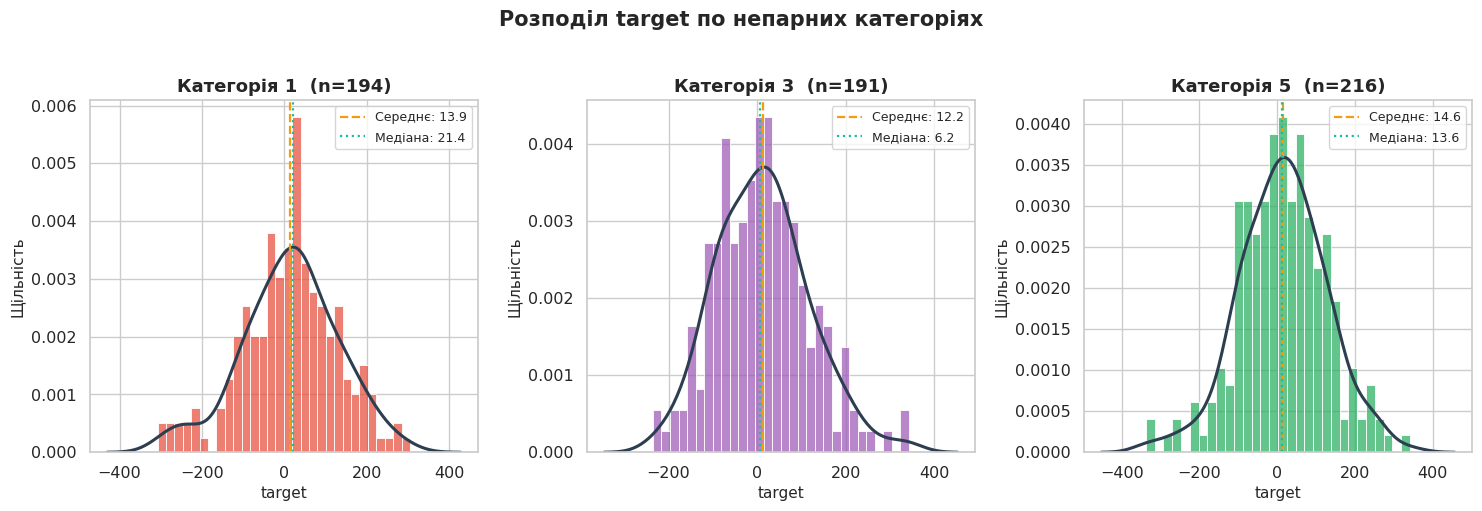

In [ ]:
PALETTE = {1: "#e74c3c", 3: "#9b59b6", 5: "#27ae60"}

fig, axes = plt.subplots(1, len(odd_cats), figsize=(5 * len(odd_cats), 5), sharey=False)

for ax, cat in zip(axes, odd_cats):
    sub   = df[df['category'] == cat]['target']
    color = PALETTE.get(cat, "#3498db")

    sns.histplot(sub, bins=BINS_CAT, ax=ax,
                 color=color, edgecolor="white", linewidth=0.6,
                 stat="density", alpha=0.72)

    sns.kdeplot(sub, ax=ax, color="#2c3e50", linewidth=2.2)

    ax.set_title(f"Категорія {cat}  (n={len(sub)})", fontsize=13, fontweight="bold")
    ax.set_xlabel("target", fontsize=11)
    ax.set_ylabel("Щільність", fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle("Розподіл target по непарних категоріях", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
